## Loading the dataset and summary

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("training.csv")

print("First 5 Rows:")
display(train_df.head())

print("\nDataset Shape:")
print(f"Rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")



First 5 Rows:


,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0



Dataset Shape:
Rows: 12906, Columns: 83


In [30]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 83 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             12906 non-null  int64  
 1   patient_race                           6521 non-null   object 
 2   payer_type                             11103 non-null  object 
 3   patient_state                          12855 non-null  object 
 4   patient_zip3                           12906 non-null  int64  
 5   patient_age                            12906 non-null  int64  
 6   patient_gender                         12906 non-null  object 
 7   bmi                                    3941 non-null   float64
 8   breast_cancer_diagnosis_code           12906 non-null  object 
 9   breast_cancer_diagnosis_desc           12906 non-null  object 
 10  metastatic_cancer_diagnosis_code       12906 non-null  object 
 11  me

loading test data


In [31]:
test_df = pd.read_csv("test.csv")

print("First 5 Rows:")
display(test_df.head())

print("\nDataset Shape:")
print(f"Rows: {test_df.shape[0]}, Columns: {test_df.shape[1]}")

First 5 Rows:


,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02
0,573710,White,MEDICAID,IN,467,54,F,NaN,C50412,Malig neoplasm of upper-outer quadrant of left...,...,3.564516,13.996774,7.985484,0.969355,24.955357,10.838710,8.080645,38.724876,7.947165,11.157161
1,593679,NaN,COMMERCIAL,FL,337,52,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,10.261538,16.020513,13.602564,2.836842,23.952632,10.579487,9.302564,36.918257,7.838973,13.599985
2,184532,Hispanic,MEDICAID,CA,917,61,F,NaN,C50911,Malignant neoplasm of unsp site of right femal...,...,47.726087,9.895652,10.515217,12.745652,32.530435,7.263043,3.810870,47.310325,9.595719,20.084231
3,447383,Hispanic,MEDICARE ADVANTAGE,CA,917,64,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,47.726087,9.895652,10.515217,12.745652,32.530435,7.263043,3.810870,47.310325,9.595719,20.084231
4,687972,Black,NaN,CA,900,40,F,23.0,C50412,Malig neoplasm of upper-outer quadrant of left...,...,45.526154,11.901538,20.760000,14.737500,30.709375,10.341538,3.030769,41.186992,11.166898,21.644261



Dataset Shape:
Rows: 5792, Columns: 82


## Data Cleaning

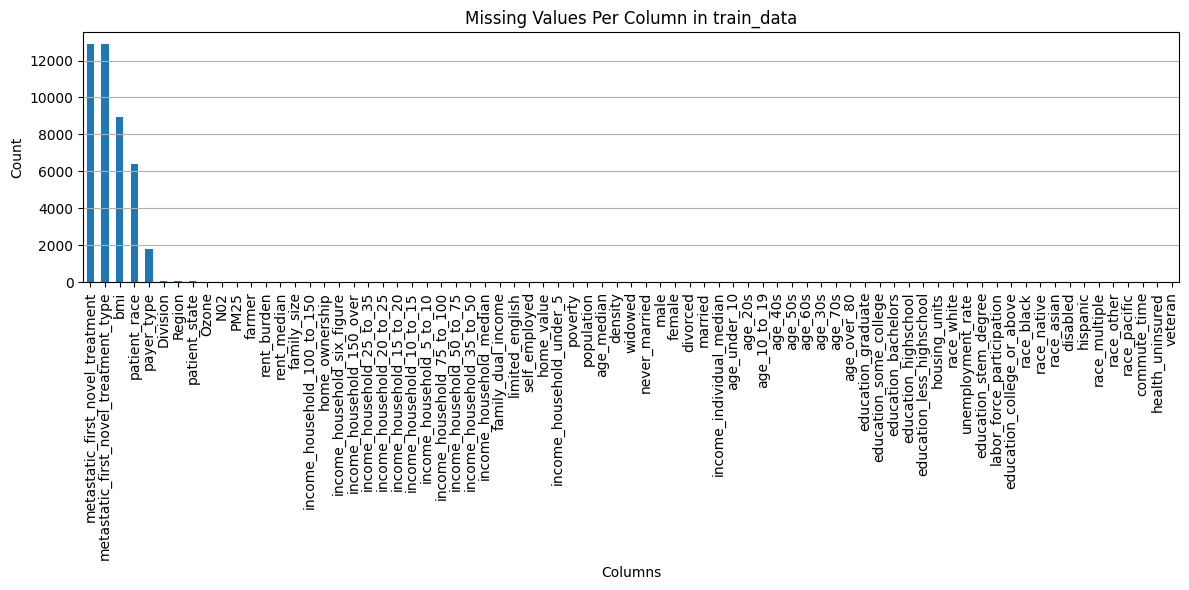

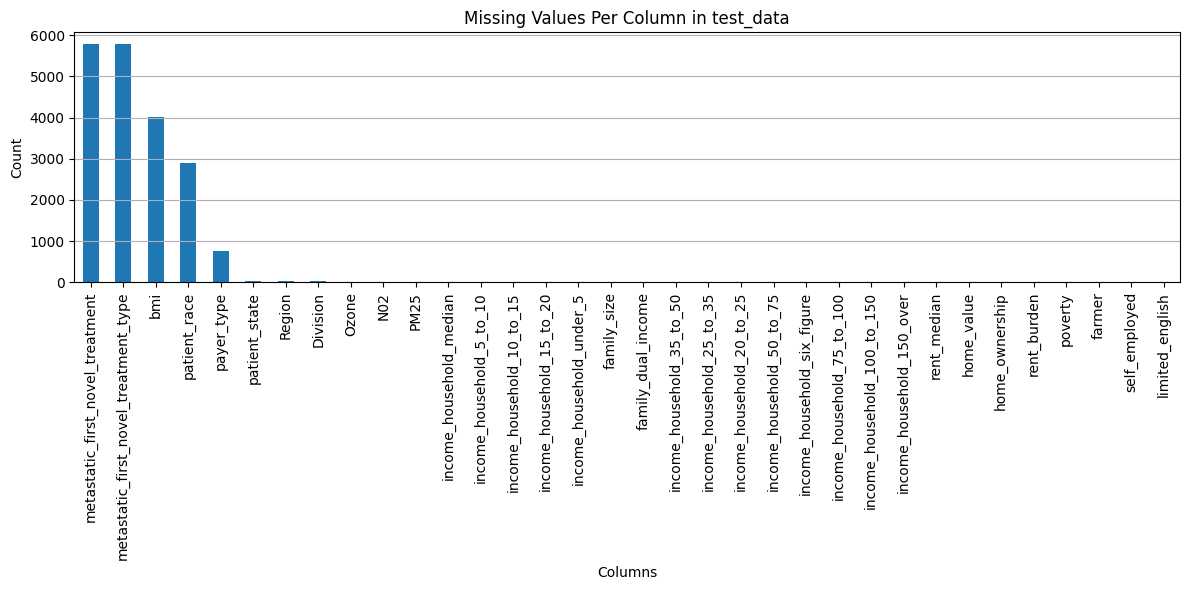

In [32]:
import matplotlib.pyplot as plt

# Count and sort missing values
missing_counts = train_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
missing_counts.plot(kind='bar')
plt.title("Missing Values Per Column in train_data")
plt.ylabel("Count")
plt.xlabel("Columns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

# Count and sort missing values
missing_counts = test_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
missing_counts.plot(kind='bar')
plt.title("Missing Values Per Column in test_data")
plt.ylabel("Count")
plt.xlabel("Columns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()



In [33]:
# Dropping columns mostly missing values
cols_to_drop = ['metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type']
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

# Impute BMI with median
bmi_median = train_df['bmi'].median()
train_df['bmi'] = train_df['bmi'].fillna(bmi_median)
test_df['bmi'] = test_df['bmi'].fillna(bmi_median)

# Impute categorical values using median
cat_cols = ['patient_race', 'payer_type', 'Division', 'Region']
for col in cat_cols:
    mode_value = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_value)
    test_df[col] = test_df[col].fillna(mode_value)


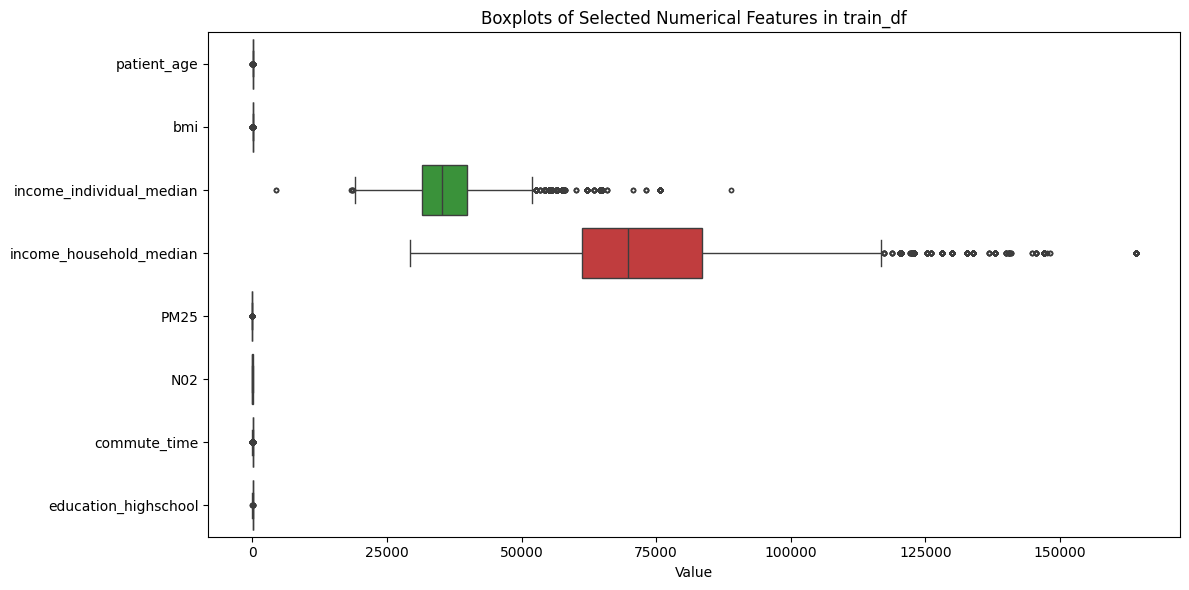

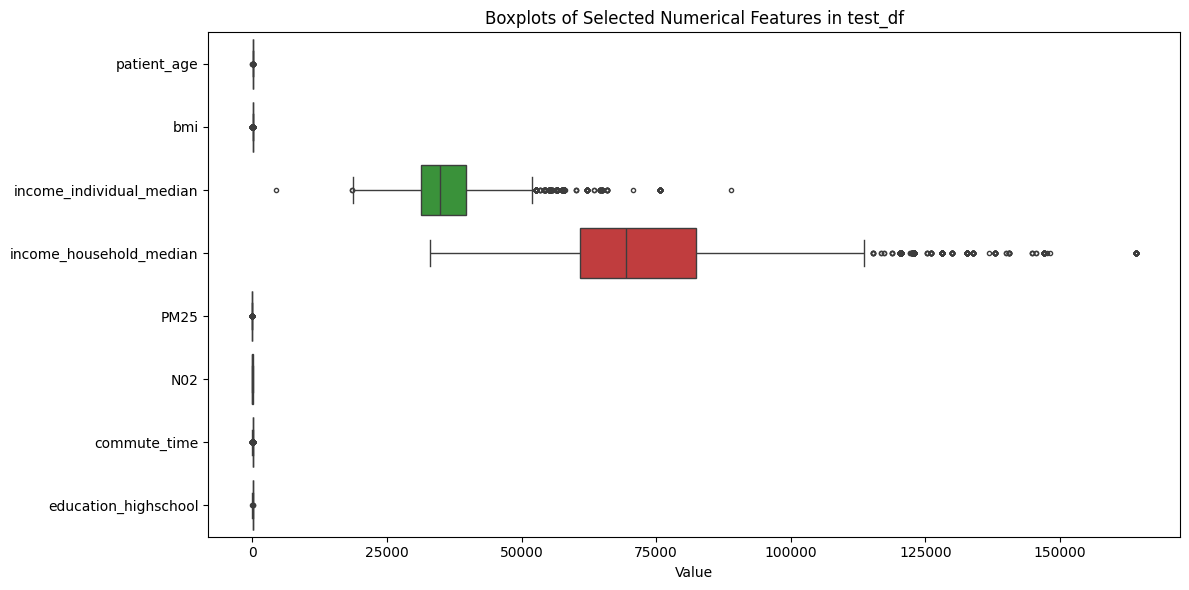

In [34]:
# Selected relevant numerical columns to check for outliers
requested_cols = [
    'patient_age',
    'bmi',
    'income_individual_median',
    'income_household_median',
    'ozone',
    'PM25',
    'N02',
    'commute_time',
    'education_highschool'
]


selected_numerical = [col for col in requested_cols if col in train_df.columns]

# Plot boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df[selected_numerical], orient='h', fliersize=3, linewidth=1)
plt.title("Boxplots of Selected Numerical Features in train_df")
plt.xlabel("Value")
plt.tight_layout()
plt.show()


# Plot boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=test_df[selected_numerical], orient='h', fliersize=3, linewidth=1)
plt.title("Boxplots of Selected Numerical Features in test_df")
plt.xlabel("Value")
plt.tight_layout()
plt.show()





Seeing that outliers are mostly in median income, we let it as it is, since incomes may vary vastly amongt different patients.

In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 81 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patient_id                        12906 non-null  int64  
 1   patient_race                      12906 non-null  object 
 2   payer_type                        12906 non-null  object 
 3   patient_state                     12855 non-null  object 
 4   patient_zip3                      12906 non-null  int64  
 5   patient_age                       12906 non-null  int64  
 6   patient_gender                    12906 non-null  object 
 7   bmi                               12906 non-null  float64
 8   breast_cancer_diagnosis_code      12906 non-null  object 
 9   breast_cancer_diagnosis_desc      12906 non-null  object 
 10  metastatic_cancer_diagnosis_code  12906 non-null  object 
 11  Region                            12906 non-null  object 
 12  Divi

## Feature Engineering - Label Encoding

In [37]:
from sklearn.preprocessing import LabelEncoder

# Step 0: Define categorical and numeric columns
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Optional: remove identifiers or target from numeric_cols if present
for col in ['patient_id', 'DiagPeriodL90D']:
    if col in numeric_cols:
        numeric_cols.remove(col)

# Step 1: Encode categorical variables in train_df
label_encoders = {}
for col in categorical_cols:
    if train_df[col].isnull().sum() > 0:
        train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    label_encoders[col] = le

# Step 2: Impute numeric columns in test_df using training stats
for col in numeric_cols:
    if col in test_df.columns and test_df[col].isnull().sum() > 0:
        test_df[col] = test_df[col].fillna(train_df[col].mean())

# Step 3: Encode categorical columns in test_df using train_df encoders
for col in categorical_cols:
    if col in test_df.columns:
        if test_df[col].isnull().sum() > 0:
            test_df[col] = test_df[col].fillna(train_df[col].mode()[0])
        le = label_encoders[col]
        test_df[col] = test_df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

# Final check
train_df.info()
test_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 81 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patient_id                        12906 non-null  int64  
 1   patient_race                      12906 non-null  int64  
 2   payer_type                        12906 non-null  int64  
 3   patient_state                     12906 non-null  int64  
 4   patient_zip3                      12906 non-null  int64  
 5   patient_age                       12906 non-null  int64  
 6   patient_gender                    12906 non-null  int64  
 7   bmi                               12906 non-null  float64
 8   breast_cancer_diagnosis_code      12906 non-null  int64  
 9   breast_cancer_diagnosis_desc      12906 non-null  int64  
 10  metastatic_cancer_diagnosis_code  12906 non-null  int64  
 11  Region                            12906 non-null  int64  
 12  Divi

## Data Visualization

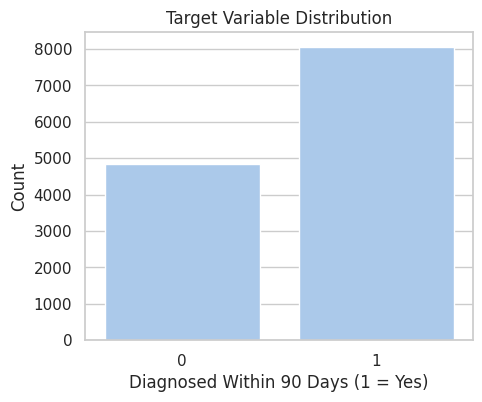

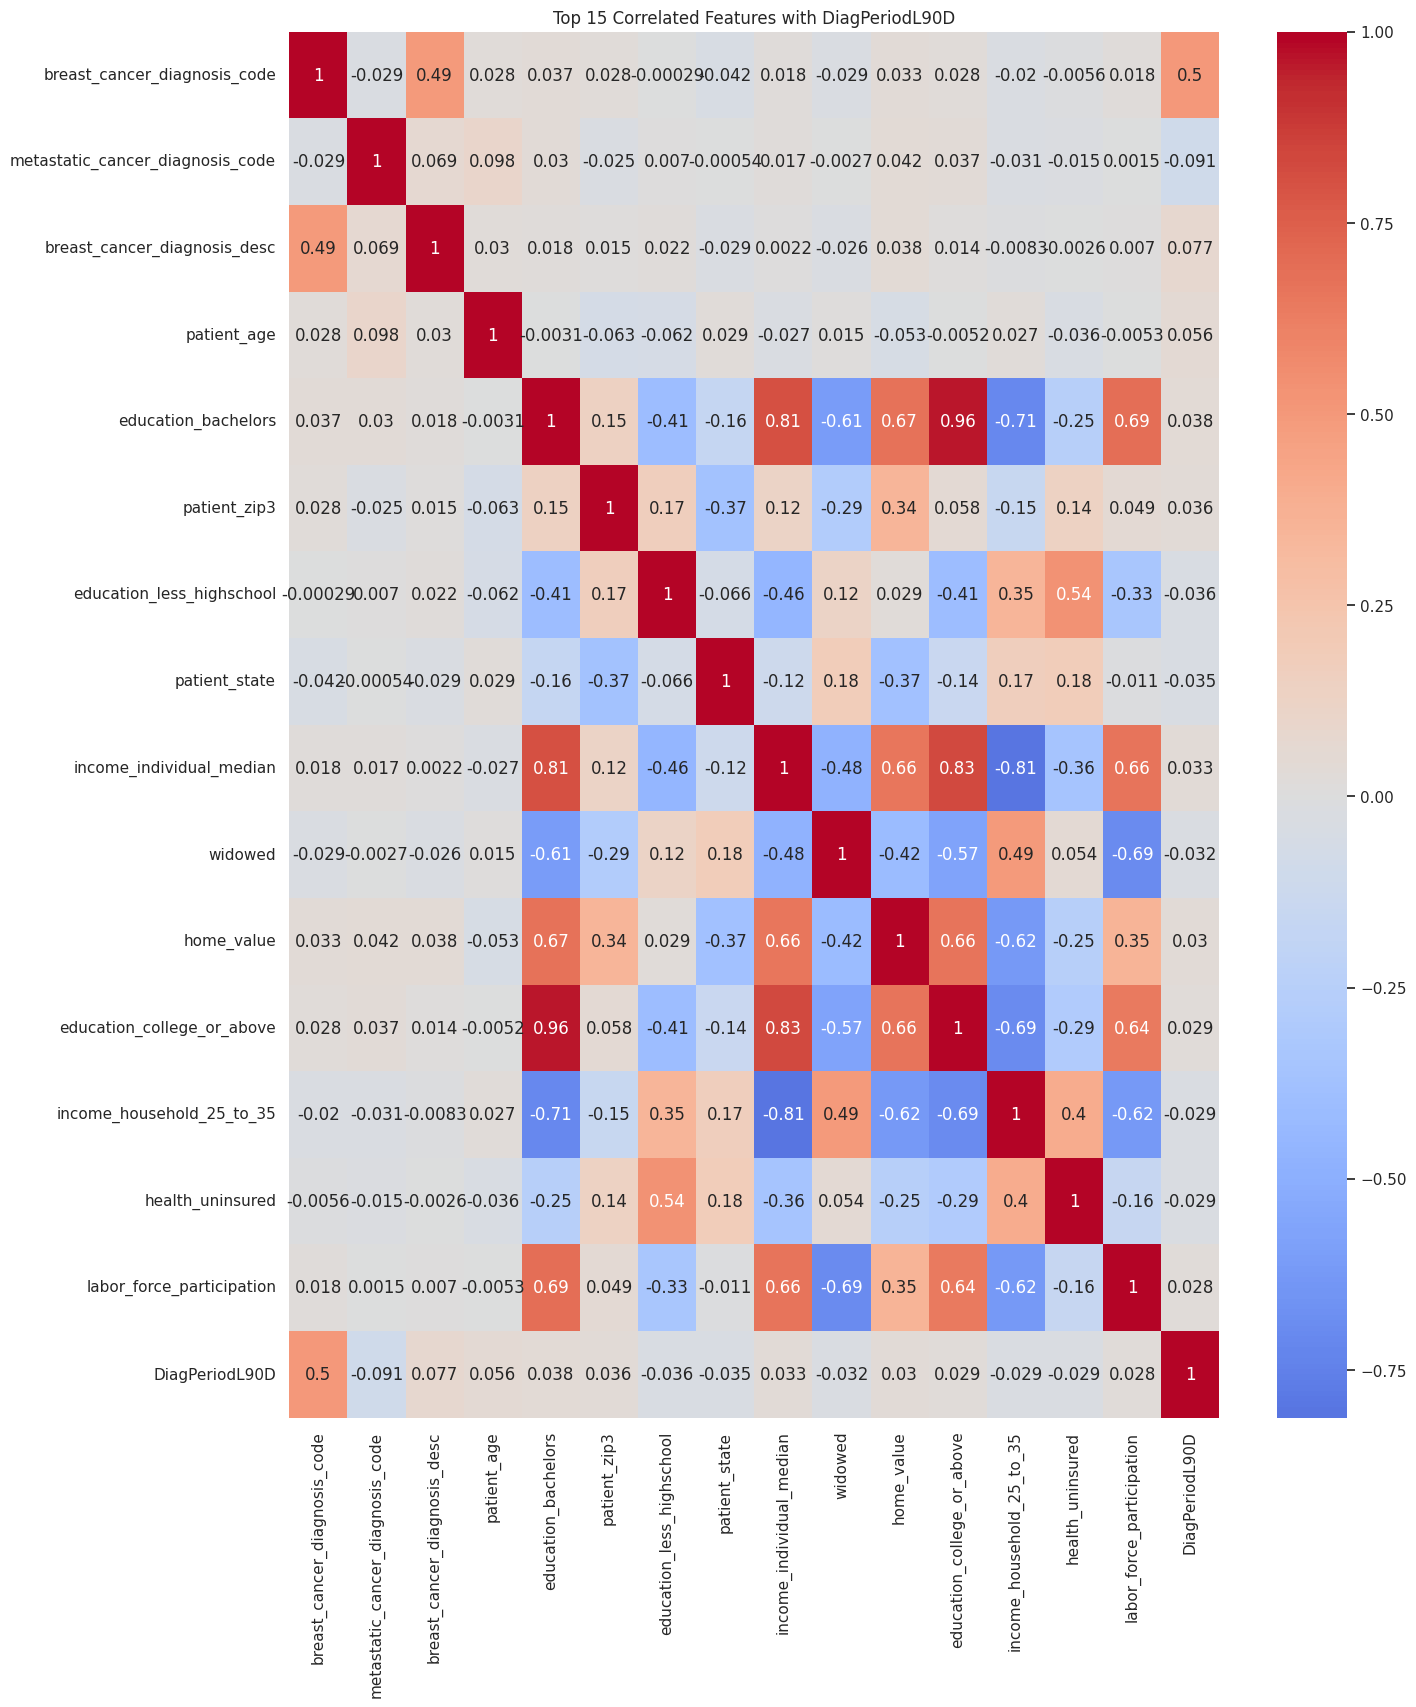

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='whitegrid', palette='pastel')

# Distribution of Target Variable
plt.figure(figsize=(5, 4))
sns.countplot(x='DiagPeriodL90D', data=train_df)
plt.title('Target Variable Distribution')
plt.xlabel('Diagnosed Within 90 Days (1 = Yes)')
plt.ylabel('Count')
plt.show()

# Correlation HeatMap
top_corr = train_df.corr(numeric_only=True)['DiagPeriodL90D'].abs().sort_values(ascending=False)[1:16]
plt.figure(figsize=(15, 18))
sns.heatmap(train_df[top_corr.index.tolist() + ['DiagPeriodL90D']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Top 15 Correlated Features with DiagPeriodL90D')
plt.show()

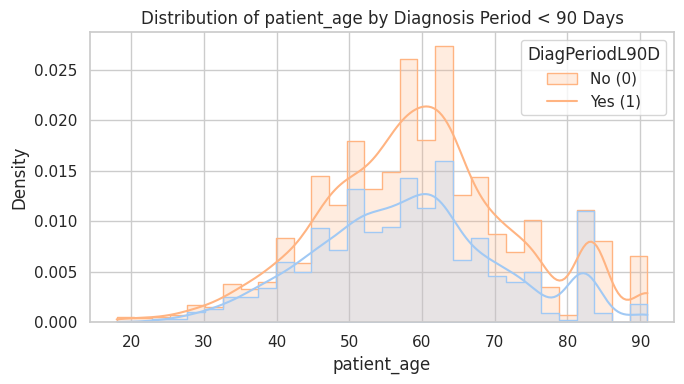

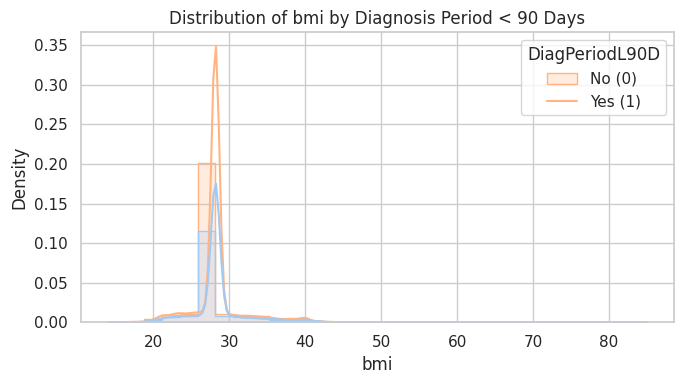

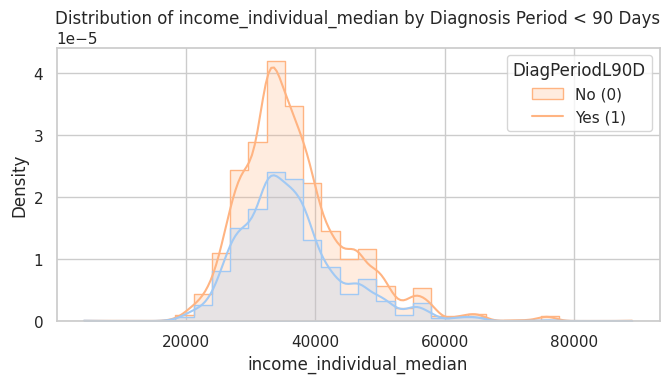

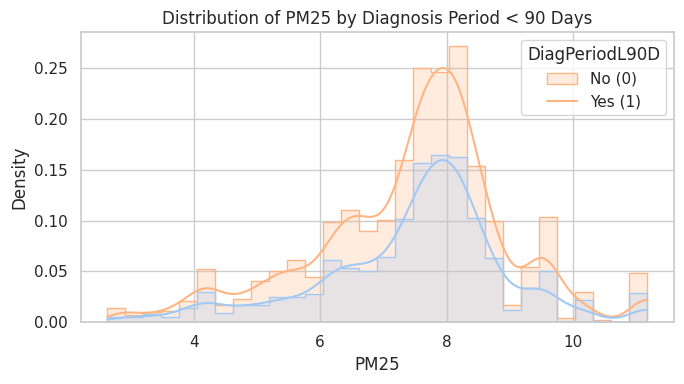

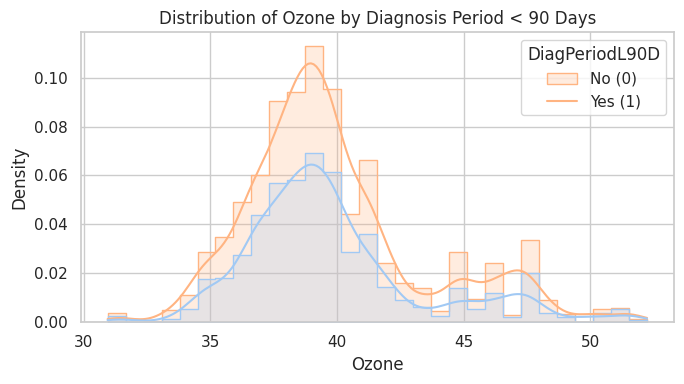

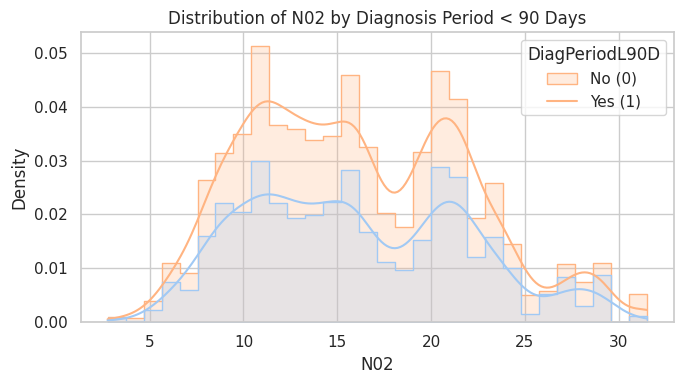

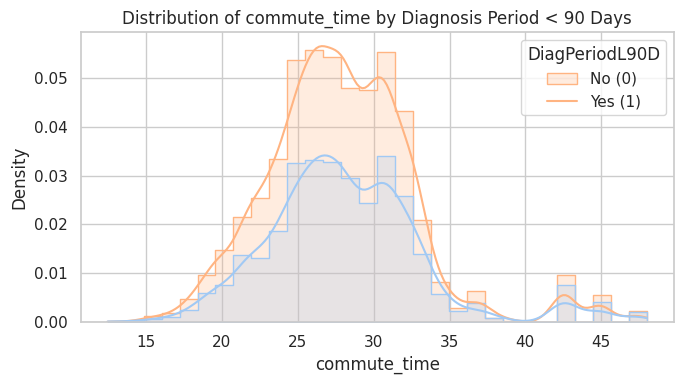

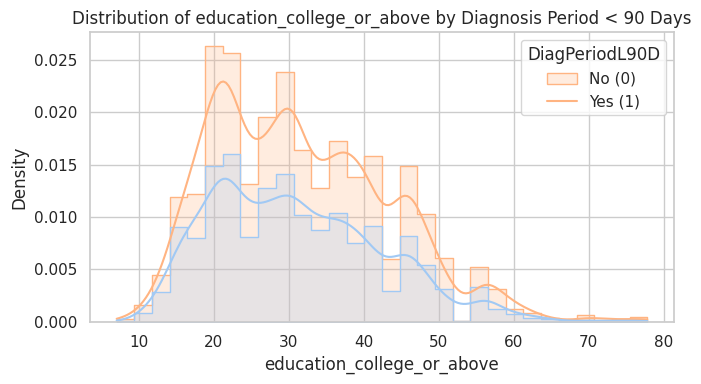

In [41]:


# Selected features for distribution visualization
selected_features = [
    'patient_age',
    'bmi',
    'income_individual_median',
    'PM25',
    'Ozone',
    'N02',
    'commute_time',
    'education_college_or_above'
]

# Plot histograms for each feature by target class
for feature in selected_features:
    if feature in train_df.columns:
        plt.figure(figsize=(7, 4))
        sns.histplot(data=train_df, x=feature, hue='DiagPeriodL90D', bins=30, kde=True, element='step', stat='density')
        plt.title(f'Distribution of {feature} by Diagnosis Period < 90 Days')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend(title='DiagPeriodL90D', labels=['No (0)', 'Yes (1)'])
        plt.tight_layout()
        plt.show()


## Logistic Regression


=== Logistic Regression Evaluation ===
Confusion Matrix:
 [[ 584  381]
 [ 153 1464]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.61      0.69       965
           1       0.79      0.91      0.85      1617

    accuracy                           0.79      2582
   macro avg       0.79      0.76      0.77      2582
weighted avg       0.79      0.79      0.79      2582

ROC AUC Score: 0.7797629461582088


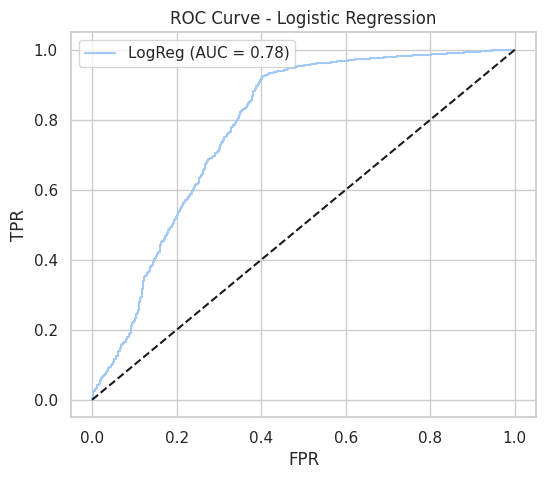

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

#Define features and target
X = train_df.drop(columns=['DiagPeriodL90D', 'patient_id'])
y = train_df['DiagPeriodL90D']

#Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Impute missing values using training means
X_train = X_train.fillna(X_train.mean())
X_val = X_val.fillna(X_train.mean())  # use training mean to prevent leakage

#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#Train model
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_scaled, y_train)

#Evaluate on validation set
y_pred = logreg.predict(X_val_scaled)
y_prob = logreg.predict_proba(X_val_scaled)[:, 1]

print("=== Logistic Regression Evaluation ===")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("ROC AUC Score:", roc_auc_score(y_val, y_prob))

# The ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc_score(y_val, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True)
plt.show()

#Predict on test_df
X_test = test_df[X.columns]
X_test = X_test.fillna(X_train.mean())  # use training mean for test set
X_test_scaled = scaler.transform(X_test)
test_probs = logreg.predict_proba(X_test_scaled)[:, 1]



## Random Forest Classifier Models



Basic Random Forest Classifier

=== Basic Random Forest Evaluation ===
Confusion Matrix:
 [[ 576  389]
 [ 195 1422]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.66       965
           1       0.79      0.88      0.83      1617

    accuracy                           0.77      2582
   macro avg       0.77      0.74      0.75      2582
weighted avg       0.77      0.77      0.77      2582

ROC AUC Score: 0.77078611001631


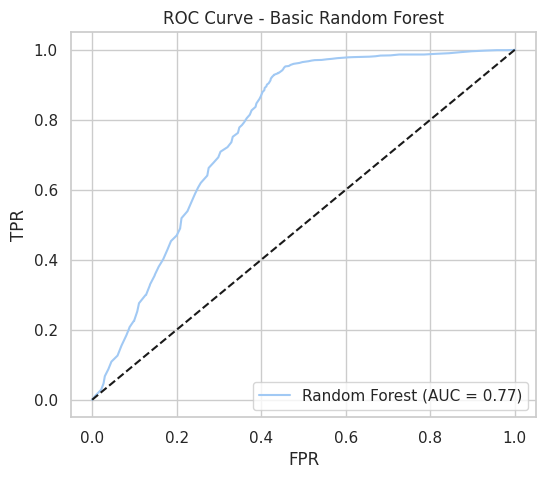

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

#Define features and target
X = train_df.drop(columns=['DiagPeriodL90D', 'patient_id'])
y = train_df['DiagPeriodL90D']

#Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Impute missing values
X_train = X_train.fillna(X_train.mean())
X_val = X_val.fillna(X_train.mean())

#Train basic Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

#Evaluate
y_pred = rf.predict(X_val)
y_prob = rf.predict_proba(X_val)[:, 1]

print("=== Basic Random Forest Evaluation ===")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("ROC AUC Score:", roc_auc_score(y_val, y_prob))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_val, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Basic Random Forest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True)
plt.show()

# Predict on test_df
X_test = test_df[X.columns]
X_test = X_test.fillna(X_train.mean())
test_probs_rf = rf.predict_proba(X_test)[:, 1]


Manually Tuned Random Forest

=== Manually Tuned Random Forest Evaluation ===
Confusion Matrix:
 [[ 580  385]
 [ 143 1474]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69       965
           1       0.79      0.91      0.85      1617

    accuracy                           0.80      2582
   macro avg       0.80      0.76      0.77      2582
weighted avg       0.80      0.80      0.79      2582

ROC AUC Score: 0.7821860350357759


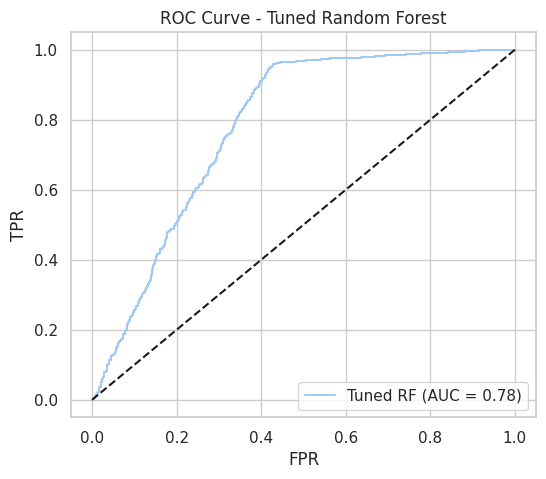

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Define features and target
X = train_df.drop(columns=['DiagPeriodL90D', 'patient_id'])
y = train_df['DiagPeriodL90D']

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values using training-set mean
X_train = X_train.fillna(X_train.mean())
X_val = X_val.fillna(X_train.mean())

# Manually tuned Random Forest
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_train, y_train)

# Evaluation on validation set
y_pred = best_rf.predict(X_val)
y_prob = best_rf.predict_proba(X_val)[:, 1]

print("=== Manually Tuned Random Forest Evaluation ===")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("ROC AUC Score:", roc_auc_score(y_val, y_prob))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Tuned RF (AUC = {roc_auc_score(y_val, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Tuned Random Forest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True)
plt.show()

#Predict on test_df
X_test = test_df[X.columns]
X_test = X_test.fillna(X_train.mean())
test_probs_rf = best_rf.predict_proba(X_test)[:, 1]


